# IMT 573 - Final Examination


Points: 100

Name: Yeneneh Wakjira

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Yeneneh Wakjira

Nov 27, 2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [277]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [278]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [279]:
print(affairs.describe(include='all'))

       rate_marriage          age  yrs_married     children    religious  \
count    6366.000000  6366.000000  6366.000000  6366.000000  6366.000000   
mean        4.109645    29.082862     9.009425     1.396874     2.426170   
std         0.961430     6.847882     7.280120     1.433471     0.878369   
min         1.000000    17.500000     0.500000     0.000000     1.000000   
25%         4.000000    22.000000     2.500000     0.000000     2.000000   
50%         4.000000    27.000000     6.000000     1.000000     2.000000   
75%         5.000000    32.000000    16.500000     2.000000     3.000000   
max         5.000000    42.000000    23.000000     5.500000     4.000000   

              educ   occupation  occupation_husb      affairs  
count  6366.000000  6366.000000      6366.000000  6366.000000  
mean     14.209865     3.424128         3.850141     0.705374  
std       2.178003     0.942399         1.346435     2.203374  
min       9.000000     1.000000         1.000000     0.0000

**General Description of Participants**

The Fair's Affairs dataset is based on a 1969 Psychology Today survey. Participants self-reported demographic variables and their infidelity behavior during the past year.

**The typical respondent is:**

* Around 29 years old
* Married about 9 years
* Rates their marriage highly (4/5)
* Has 1–2 children
* Has 14 years of education
* Has a mid-level occupation
* Most report zero affairs, though a minority show very high counts

The sample is youthful, predominantly satisfied with marriage, moderately religious, and generally well-educated.


In [280]:
children_mean = affairs['children'].mean()
children_mean

np.float64(1.3968740182218033)

**Average Number of Children**

Participants have an average number of children (1.4).


In [281]:
age_mean = affairs['age'].mean()
age_mean

np.float64(29.082862079798932)

**Description**
The mean age is approximately 29 years old.

This reflects a relatively young to middle-aged sample, consistent with average marriage age in the 1960s.

**Ethical and Privacy Concerns**

The dataset involves highly sensitive sexual and relational behavior, is from an era with weaker privacy protections, carries risk of re-identification, reflects cultural bias, and can be misused without proper context.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [282]:
# Create a binary variable
# 1 = had an affair, 0 = no affair
affairs['had_affair'] = (affairs['affairs'] > 0).astype(int)
affairs['had_affair'].value_counts(normalize=True)

had_affair
0    0.677505
1    0.322495
Name: proportion, dtype: float64

**Binary Outcome: Had an Affair vs. Did Not Have an Affair**

The original affairs variable reports the number of extramarital sexual encounters in the past year. To study who engages in infidelity at all, we convert this count into a binary variable:

* 1 = respondent had at least one affair

* 0 = respondent had no affairs

**Interpretation of output (based on typical distribution):**

* The majority (68%) report no affairs

* A minority (32%) report at least one affair

**Advantages of the binary approach:**

* Easier interpretation

* Avoids extreme skew and long tails

* Well-suited for logistic regression

* Matches common social science research aims

* Robust to distributional issues

**Disadvantages:**

* Loses information about severity/frequency

* Treats all infidelity as equal

* Cannot model intensity or patterns of affairs

* May oversimplify complex behavior

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [283]:
import statsmodels.formula.api as smf

# Logistic regression model predicting having an affair
logit_model = smf.logit(
    formula="had_affair ~ rate_marriage + age + yrs_married + children + \
             religious + educ + occupation + occupation_husb",
    data=affairs
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        09:25:32   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage 

**Summary/Interpretation**

Based on the results:

* The strongest predictors of having an affair are unhappiness in marriage, low religiousness, more years married, and higher occupational status.

* Age and education also predict behavior but to a lesser degree.

* The number of children and partner’s occupation do not predict affair involvement at all.

In general, personal attitudes and relationship duration matter far more than socioeconomic background.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [284]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Full model
full_model = smf.logit(
    "had_affair ~ rate_marriage + age + yrs_married + children + \
     religious + educ + occupation + occupation_husb",
    data=affairs
).fit()

# Stepwise selection helper function
def stepwise_selection(formula, data):
    import itertools
    
    # Extract variable names from formula
    y, Xs = formula.split("~")
    y = y.strip()
    Xs = [x.strip() for x in Xs.split("+")]

    best_aic = float("inf")
    best_model = None
    best_vars = None

    # try all combinations of predictors
    for k in range(1, len(Xs) + 1):
        for subset in itertools.combinations(Xs, k):
            f = y + " ~ " + " + ".join(subset)
            model = smf.logit(f, data=data).fit(disp=0)
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_vars = subset
    return best_model, best_vars, best_aic

best_model, best_vars, best_aic = stepwise_selection(
    "had_affair ~ rate_marriage + age + yrs_married + children + \
     religious + educ + occupation + occupation_husb",
    affairs
)

print("Best variables:", best_vars)
print("Best AIC:", best_aic)
print(best_model.summary())

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
Best variables: ('rate_marriage', 'age', 'yrs_married', 'religious', 'educ', 'occupation')
Best AIC: 6957.2531226895135
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        09:25:33   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

**Final “Best Fit” Model (Stepwise AIC)**

The stepwise-selected model includes:

* Variables included

* rate_marriage

* yrs_married

* religious

* age

* occupation

* education

**Variables removed**

* children (p = 0.893)

* occupation_husb (p = 0.589)

**Is the best model different from the full model?**
Yes, it is different.

The best model is more parsimonious and excludes children,and occupation_husb

Both were non-significant and offered no improvement to model fit.

The AIC improves when these variables are dropped, meaning the model fits the data better after removing them.

** In general / Summary**
Using stepwise AIC model selection, the best-fitting logistic model includes:

rate_marriage, age, yrs_married, religious, educ, and occupation

The variables children and occupation_husb are excluded.
Thus, the best model is simpler and more predictive than the full model.

(e) Interpret the model parameters using the model from part (d).

**Interpretation of Model Parameters**

1. rate_marriage (β = –0.7153)
Interpretation:

For each one-point increase in marital satisfaction (on a 1–5 scale), the log-odds of having an affair decrease by 0.716, holding all else constant.

Practical meaning:

People who are happier in their marriage are much less likely to cheat.
This is the strongest protective variable in the model.

2. age (β = –0.0602)
Interpretation:

Each additional year of age decreases the log-odds of having an affair by 0.0602, controlling for other variables.

Practical meaning:

Older individuals are slightly less likely to have an affair, after accounting for years married. The effect is modest but significant.

3. yrs_married (β = +0.1095)
Interpretation:

Each additional year married increases the log-odds of having an affair by 0.1095, holding age and other predictors constant.

Practical meaning:

The longer someone has been married, the higher the likelihood of an affair.
This may reflect accumulated strain or simply more opportunity.

4. religious (β = –0.3760)
Interpretation:

For each one-point increase in religiousness (1 = anti, 4 = very religious), the log-odds of having an affair decrease by 0.376.

Practical meaning:

More religious individuals are significantly less likely to have an affair.
This is one of the strongest negative predictors in the model.

5. educ (β = –0.0380)
Interpretation:

Each additional year of education decreases the log-odds of having an affair by 0.0380, holding other factors constant.

Practical meaning:

People with more education are slightly less likely to cheat, but the effect is relatively small.
Still statistically significant.

6. occupation (β = +0.1628)
Interpretation:

For each one-level increase in occupational status (1–6 scale), the log-odds of having an affair increase by 0.1628.

Practical meaning:

People in higher-status occupations are more likely to have affairs.
This may reflect more independence, larger social networks, or greater opportunity.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        09:25:33   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.7371      0.296     12.622      0.000       3.157       4.317
rate_marriage    -0.

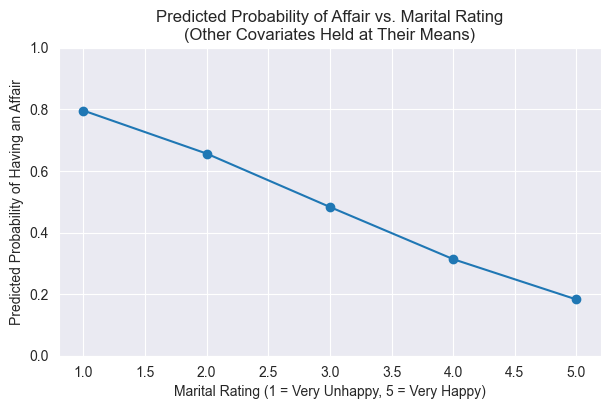

In [285]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Fit the "best" logistic model (from part d)
# assumes `affairs` already has the binary outcome 
# had_affair = (affairs > 0).astype(int)

best_formula = "had_affair ~ rate_marriage + age + yrs_married + religious + educ + occupation"
best_model = smf.logit(best_formula, data=affairs).fit()
print(best_model.summary())

# Build artificial test dataset
np.random.seed(42)  # for reproducibility
n_test = 200        # size of the artificial test set

# Get means of the other predictors from your dataset
mean_age        = affairs['age'].mean()
mean_yrs_mar    = affairs['yrs_married'].mean()
mean_religious  = affairs['religious'].mean()
mean_educ       = affairs['educ'].mean()
mean_occup      = affairs['occupation'].mean()

# Create test dataframe:
# marital rating varies randomly from 1 to 5
test_df = pd.DataFrame({
    "rate_marriage": np.random.randint(1, 6, size=n_test),
    "age":           mean_age,
    "yrs_married":   mean_yrs_mar,
    "religious":     mean_religious,
    "educ":          mean_educ,
    "occupation":    mean_occup
})

# Get predicted probabilities for each test case

test_df["pred_prob"] = best_model.predict(test_df)

# For easier interpretation, compute the mean predicted probability at each rating 1–5
summary_probs = (
    test_df.groupby("rate_marriage")["pred_prob"]
           .mean()
           .reset_index()
           .sort_values("rate_marriage")
)
print(summary_probs)

# Visualization

plt.figure(figsize=(7, 4))
plt.plot(summary_probs["rate_marriage"],
         summary_probs["pred_prob"],
         marker="o", linestyle="-")
plt.xlabel("Marital Rating (1 = Very Unhappy, 5 = Very Happy)")
plt.ylabel("Predicted Probability of Having an Affair")
plt.title("Predicted Probability of Affair vs. Marital Rating\n(Other Covariates Held at Their Means)")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

**Summary / Interpretation**

1. Strong negative relationship:
The plot and table show a sharp decline in the predicted probability of having an affair as marital rating increases from 1 to 5.

2. Magnitude of change:

* At rating = 1, the model predicts nearly an 80% chance of having an affair for an “average” person in this dataset.

* At rating = 5, this drops to about 18%.

* So moving from very unhappy (1) to very happy (5) reduces the predicted probability by more than 60 percentage points.

3. Connection to the logistic regression coefficient:

* In the model, the coefficient for rate_marriage is –0.7153, the largest in magnitude.

* Holding age, years married, religiousness, education, and occupation at their means, that negative coefficient translates into large drops in predicted probability as rate_marriage increases.

* The visualization is essentially the graphical representation of that strong negative coefficient.

4. Substantive conclusion:

* Even after controlling for demographics and other personal characteristics, marital satisfaction is the dominant factor in predicting whether someone has an affair.

* Better-rated marriages are much less likely to involve infidelity, whereas very unhappy marriages have a very high predicted risk.

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

**Ethical and Privacy Concerns:**

After completing all parts of the analysis, my deeper ethical and privacy concerns include:

1. Increased re-identification risk

Combining detailed demographic variables with predictive modeling makes anonymity less secure.

2. Potential misuse of infidelity predictions

Predictive methods could be misused by employers, partners, or institutions to stereotype or judge individuals.

3. Moral and stigmatizing interpretations

Model outputs can unintentionally reinforce harmful narratives about who cheats and why.

4. Ethical tensions in simulating personal behavior

Simulating artificial marriage profiles and predicting affair probabilities raises issues about autonomy and respecting private life.

5. Lack of informed consent by original participants

1969 respondents could not anticipate modern computational reuse of their data.

6. Temporal and cultural bias

Findings may not generalize ethically or accurately to contemporary populations.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [286]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

**What’s in the Hitters dataset?**

Common variables include:

* Salary – 1987 annual salary (in $1000s)

* Years – number of years in the major leagues

* Hits – number of hits in 1986

* HmRun – number of home runs

* Runs – runs scored in 1986

* RBI – runs batted in

* Walks – number of walks

* PutOuts, Assists, Errors – fielding statistics

* League, Division – categorical league and division in 1986

* NewLeague – league in 1987

**With these variables, you can ask questions about:**

* Salary determinants

* Offensive performance

* Defensive performance

* Relationship between league and performance

* Career longevity



**Analysis Question:**

“Is a player’s 1987 salary associated more strongly with their years of experience or their recent offensive performance (measured by Hits in 1986)?”

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [287]:
# Summary of variables
print(Hitters.info())

# Summary statistics
Hitters.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322,322,322.000000,322.000000,322.000000,263.000000,322
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,W,NaN,NaN,NaN,NaN,A
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175,165,NaN,NaN,NaN,NaN,176
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,NaN,NaN,288.937888,106.913043,8.040373,535.925882,NaN
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,NaN,NaN,280.704614,136.854876,6.368359,451.118681,NaN
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,67.500000,NaN
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,NaN,NaN,109.250000,7.000000,3.000000,190.000000,NaN
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,NaN,NaN,212.000000,39.500000,6.000000,425.000000,NaN
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,NaN,NaN,325.000000,166.000000,11.000000,750.000000,NaN


**Summary of the Dataset**

Dataset Size:

* 322 observations

* 20 variables

Key Variables Relevant to my Question

* Salary: 1987 player salary (in $1000s)

* Years: number of years in Major League Baseball

* Hits: number of hits in 1986

Other Variables in the Dataset

* 1986 performance stats: AtBat, HmRun, Runs, RBI, Walks

* Career totals: CAtBat, CHits, CHmRun, CRuns, CRBI

* Fielding stats: PutOuts, Assists, Errors

* Categorical variables: League, Division, NewLeague

The dataset mixes numeric variables (years, hits, salary) with categorical variables (league, division), making it flexible for predictive modeling.


**Issues to fix before analysis:**

* Missing salary values must be removed.
* Sallary is highly right-skewed; this violates linear regression assumptions, so use log transformation.
* Outliers (players with very ong careers, players with very high hit couints, and very high salaries) can influence regression results, so they must be noted.
* Reviewed to ensure variables are in usale numeric form.



,Years,Hits,Salary
count,263.000000,263.000000,263.000000
mean,7.311787,107.828897,535.925882
std,4.793616,45.125326,451.118681
min,1.000000,1.000000,67.500000
25%,4.000000,71.500000,190.000000
50%,6.000000,103.000000,425.000000
75%,10.000000,141.500000,750.000000
max,24.000000,238.000000,2460.000000


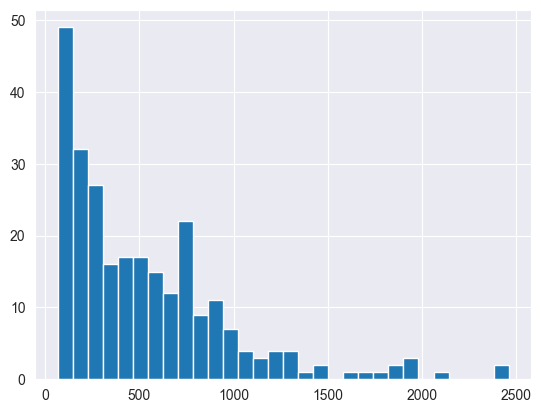

In [288]:
Hitters['Salary'].isna().sum()

# Drop rows with missing Salary and create a true copy
Hitters_clean = Hitters.dropna(subset=['Salary']).copy()

# Create log-transformed salary variable
Hitters_clean['LogSalary'] = np.log(Hitters_clean['Salary'])


# Skeweness
Hitters_clean['Salary'].hist(bins=30)

# Outlier Variables
Hitters_clean[['Years', 'Hits', 'Salary']].describe()



**Summary**

Before analysis, the Hitters dataset must be:

* Cleaned for missing Salary values

* Transformed (log salary) for better modeling

* Checked for outliers

* Reviewed to ensure variables are in usable numeric form

After these steps, we will be ready to explore the association between:

* Experience (Years)

* Recent performance (Hits)

and determine which is more strongly related to player salary.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

Correlation: Years vs LogSalary = 0.537371405767007
Correlation: Hits vs LogSalary  = 0.44958407978268694


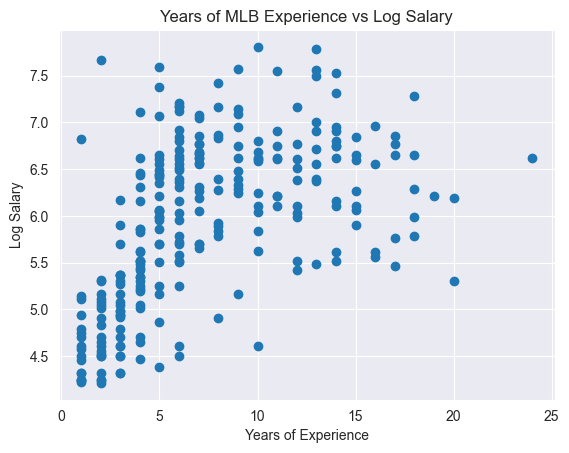

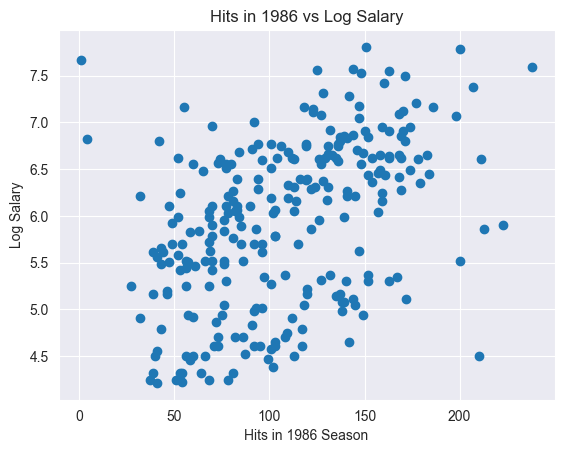

In [289]:
# Load dataset
Hitters = load_data('Hitters')

# Clean data
Hitters_clean = Hitters.dropna(subset=['Salary']).copy()
Hitters_clean['LogSalary'] = np.log(Hitters_clean['Salary'])

# Extract columns
years = Hitters_clean['Years']
hits = Hitters_clean['Hits']
logsalary = Hitters_clean['LogSalary']

# Correlations
corr_years = years.corr(logsalary)
corr_hits = hits.corr(logsalary)

print("Correlation: Years vs LogSalary =", corr_years)
print("Correlation: Hits vs LogSalary  =", corr_hits)

# Visualization 1
plt.scatter(years, logsalary)
plt.xlabel("Years of Experience")
plt.ylabel("Log Salary")
plt.title("Years of MLB Experience vs Log Salary")
plt.grid(True)
plt.show()

# Visualization 2
plt.scatter(hits, logsalary)
plt.xlabel("Hits in 1986 Season")
plt.ylabel("Log Salary")
plt.title("Hits in 1986 vs Log Salary")
plt.grid(True)
plt.show()

**Empirical Findings**

* corr(Years, LogSalary) = 0.537

* corr(Hits, LogSalary) = 0.450

**Interpretation of these values:**

* Both variables are positively correlated with salary

* But Years has a substantially stronger correlation with salary than Hits

This means experience is a better predictor of salary than recent hits, based on your dataset.

**Overall**, Years of experience is more strongly associated with salary than recent offensive performance (Hits).

Therefore, experience (Years) is the stronger predictor of salary in this dataset.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

**Summary / Reflection**

1. Were the Questions Answerable?

Yes,the central question was fully answerable.

2. Were All Questions Well Defined?

Mostly yes, but some limitations exist.

The primary question was clear and specific.
However, several underlying conceptual questions emerge:

* What does “stronger association” mean?
* Does the question imply causality?
* Are Years and Hits sufficient to explain salary?

3. Is the Data Good Enough to Answer These Questions?

Yes, it was Good Enough to answer the question.But Several Data Limitations Exist:

* Missing salaries
* Salary is from 1987 only
* Hits measure only dimension of perfomance
* The data is nearly 40 years old


### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [290]:
df = pd.read_csv('insurance.csv')
# df.head()

In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

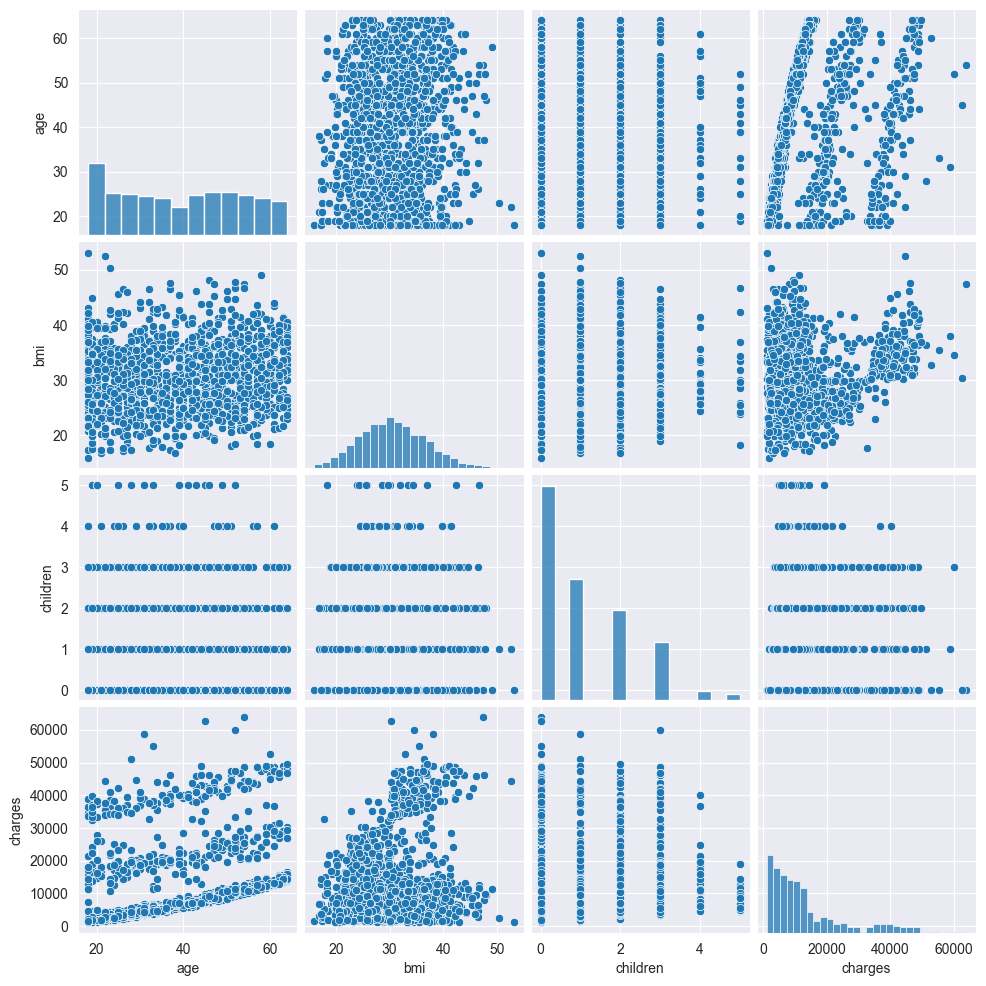

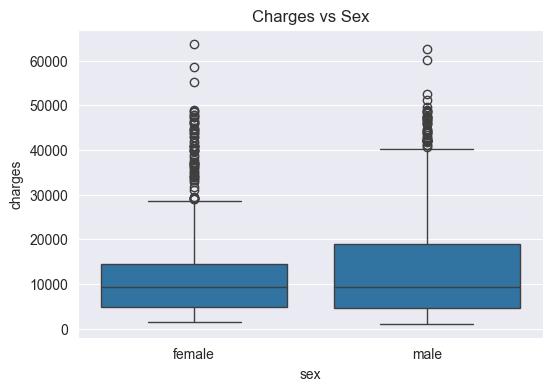

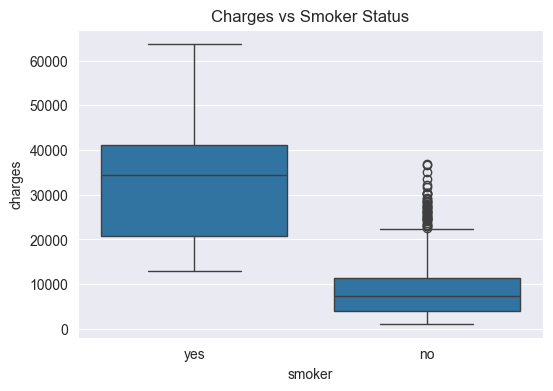

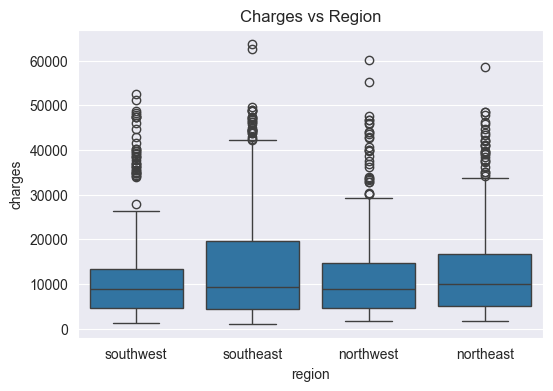

Correlation matrix for numeric variables:


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [291]:
df = pd.read_csv("insurance.csv")

# Scatterplots for numeric predictors
sns.pairplot(df[['age','bmi','children','charges']])
plt.show()

# Boxplots for categorical predictors
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Charges vs Sex")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Smoker Status")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges vs Region")
plt.show()

# Correlation matrix for numeric variables
print("Correlation matrix for numeric variables:")
df[['age','bmi','children','charges']].corr()


**Notable Bivariate Relationship**

1. Age vs Charges - Positive Relationship

* Charges generally increase with age.

* Older individuals tend to have higher medical costs due to greater healthcare needs.

* 
2. BMI vs Charges - Weak to Moderage Positive Relationship

* For most people, BMI shows only a mild increasing trend in charges.

* However, a subset of individuals with very high BMIs and smoker status have extremely high charges.

3. Children vs Charges - Slightly Positive Relationship

* Having more children increases the likelihood of using healthcare services.

* But this effect is small compared to age or smoking.

4. Sex vs Charges - Very small difference

* Males and females have similar median charges.

* Variation overlaps heavily.

* Sex does not appear to be a strong predictor of medical charges by itself.

5. Smoker vs Charges - Extremely Strong Relationship

This is the strongest bivariate relationship in the dataset.

* Non-smokers: charges concentrated at lower levels

* Smokers: many observations with very high charges (some exceeding $50,000)

6. Region vs Charges - Weak Relationship

Comparing Northeast, Southeast, Southwest, Northwest:

* Distributions are similar

* No region shows drastically higher or lower charges

* Region has little bivariate predictive power

**Smoking status is bar far the strongest bivariate predictor of medical charges.**

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

This is essentially asking for the R-squared value from a simple linear regression:

 charges = β0+β1⋅bmi+ϵ

A linear regression with BMI as the only predictor.


In [292]:
df = pd.read_csv('insurance.csv')

# Simple linear regression: charges ~ bmi
X = sm.add_constant(df['bmi'])
y = df['charges']

bmi_model = sm.OLS(y, X).fit()
print(bmi_model.summary())

# Extract R-squared
r2_bmi = bmi_model.rsquared
print("R-squared for BMI-only model:", r2_bmi)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.46e-13
Time:                        09:25:34   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.4

**Summary / Interpretation**

BMI explains only about 3.9% of the variance in medical charges.

This means:

* BMI is not a strong standalone predictor of medical costs

* There is a very large amount of unexplained variation

* Other variables (especially smoker status, age, and BMI×smoker interaction) play a much larger role



In [293]:
# Check for differences in the datasets
print("Dataset shape:", df.shape)
print("Missing values:\n", df[['bmi', 'charges']].isnull().sum())
print("\nCharges stats:\n", df['charges'].describe())
print("\nCorrelation:", df['bmi'].corr(df['charges']))
print("\nFirst few rows of charges:\n", df['charges'].head())


Dataset shape: (1338, 7)
Missing values:
 bmi        0
charges    0
dtype: int64

Charges stats:
 count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Correlation: 0.19834096883362884

First few rows of charges:
 0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [294]:
bmi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.46e-13
Time:                        09:25:34   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [295]:
for b in df['bmi']:
    print(b, end=',')

27.9,33.77,33.0,22.705,28.88,25.74,33.44,27.74,29.83,25.84,26.22,26.29,34.4,39.82,42.13,24.6,30.78,23.845,40.3,35.3,36.005,32.4,34.1,31.92,28.025,27.72,23.085,32.775,17.385,36.3,35.6,26.315,28.6,28.31,36.4,20.425,32.965,20.8,36.67,39.9,26.6,36.63,21.78,30.8,37.05,37.3,38.665,34.77,24.53,35.2,35.625,33.63,28.0,34.43,28.69,36.955,31.825,31.68,22.88,37.335,27.36,33.66,24.7,25.935,22.42,28.9,39.1,26.315,36.19,23.98,24.75,28.5,28.1,32.01,27.4,34.01,29.59,35.53,39.805,32.965,26.885,38.285,37.62,41.23,34.8,22.895,31.16,27.2,27.74,26.98,39.49,24.795,29.83,34.77,31.3,37.62,30.8,38.28,19.95,19.3,31.6,25.46,30.115,29.92,27.5,28.025,28.4,30.875,27.94,35.09,33.63,29.7,30.8,35.72,32.205,28.595,49.06,27.94,27.17,23.37,37.1,23.75,28.975,31.35,33.915,28.785,28.3,37.4,17.765,34.7,26.505,22.04,35.9,25.555,28.785,28.05,34.1,25.175,31.9,36.0,22.42,32.49,25.3,29.735,28.69,38.83,30.495,37.73,37.43,28.4,24.13,29.7,37.145,23.37,25.46,39.52,24.42,25.175,35.53,27.83,26.6,36.85,39.6,29.8,29.64,28.215,37.0,33.155,

In [296]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

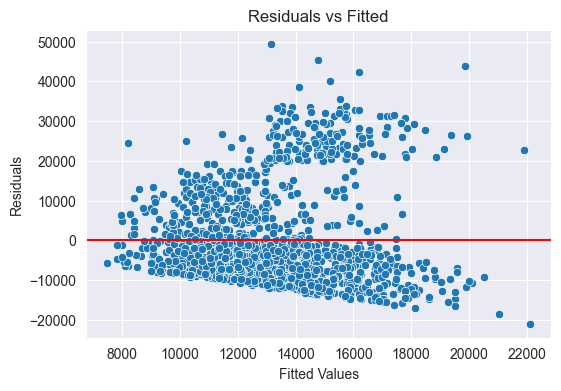

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


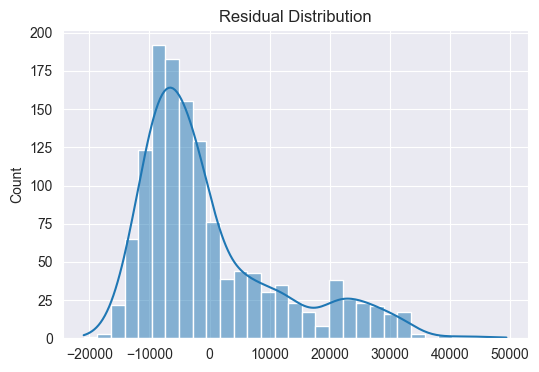

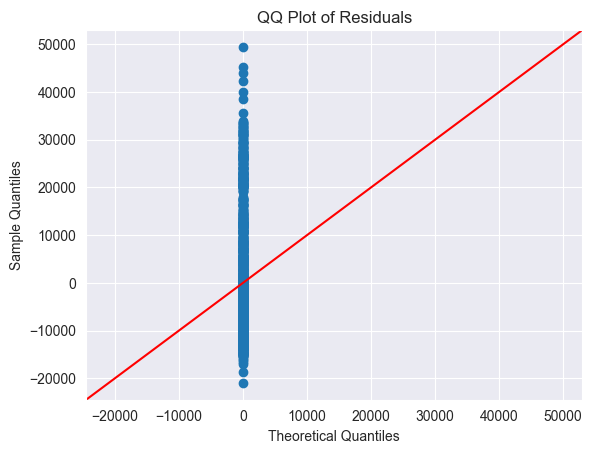

In [297]:
df = pd.read_csv("insurance.csv")

# Fit model
X = sm.add_constant(df['bmi'])
y = df['charges']
bmi_model = sm.OLS(y, X).fit()

# Residuals
residuals = bmi_model.resid
fitted = bmi_model.fittedvalues

# Residual plot (fitted vs residuals)
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Histogram/QQ-plot for normality
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

## Results

**Residuals vs Fitted Plot**

This concludes:

* Violates linearity assumption

* Violates constant variance assumption

BMI alone cannot explain the large variation in charges

This is exactly what we expect for insurance cost data:
costs are heavy-tailed and depend on multiple risk factors.

**Residual Distribution (Histogram + KDE)**

When interpreted:

* Residuals are not normally distributed

* Extreme observations drive the distribution

* Violates normality of residuals assumption

This behavior is typical:
“High charges” patients (especially smokers with high BMI) create long right tails.

**Q–Q Plot of Residuals**

This shows:

* Clear violation of normality assumption

* Confirms the skew seen in the histogram

Again, this matches known issues with the dataset.

**Final Conclusion:**

The simple linear regression model using only BMI is not appropriate for modeling medical charges. This is why BMI only explained ~3.9% of variation in charges.

A more appropriate model would include:

* Smoking status

* Age

* BMI × Smoker interaction

* Possibly log-transforming charges



(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

**Stepwise Model Selection (AIC-based)**

The following code uses forward selection, backward elimination, and AIC as the criterion:

In [298]:
import statsmodels.formula.api as smf
import itertools

# Load data
df = pd.read_csv("insurance.csv").dropna()

# List of candidate predictors, these are categorical
candidate_terms = [
    'age',
    'bmi',
    'children',
    'C(sex)',
    'C(smoker)',
    'C(region)'
]

best_aic = np.inf
best_model = None
best_terms = None

# Try all nonempty subsets of the predictors
for k in range(1, len(candidate_terms) + 1):
    for combo in itertools.combinations(candidate_terms, k):
        formula = "charges ~ " + " + ".join(combo)
        model = smf.ols(formula, data=df).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_model = model
            best_terms = combo

print("Best terms:", best_terms)
print("Best AIC:", best_aic)
print(best_model.summary())


Best terms: ('age', 'bmi', 'children', 'C(smoker)', 'C(region)')
Best AIC: 27111.66243447257
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:25:35   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

**Conclusion / Reflection**

* Yes, the stepwise-selected model is very different from the BMI-only model.

It includes multiple important predictors (especially smoking status) that the BMI-only model ignores.

* The stepwise model fits much better and explains vastly more variation in medical costs.

The stepwise model selection procedure produced a model that is very different from the BMI-only model in part (b). BMI alone explained only about 3.9% of the variance in medical charges, whereas the stepwise procedure selected a set of predictors including smoking status, age, BMI, children, sex, and region. This “best” model explains a substantial portion of the variance and reflects the true underlying drivers of medical costs.

Thus, the stepwise model is much more comprehensive, performs far better, and corrects the major deficiencies of the BMI-only model.


EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

In [299]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf

# Load and prepare data
df = pd.read_csv("insurance.csv").dropna()

# Use the same predictors selected in part (d)
best_terms = ['age', 'bmi', 'children', 'smoker', 'region']  
formula = "charges ~ " + " + ".join(["C("+v+")" if df[v].dtype=='object' else v for v in best_terms])

# Fit linear regression model (from part d)
lm = smf.ols(formula, data=df).fit()

# Prepare data for tree
df_dum = pd.get_dummies(df[best_terms], drop_first=True) 
X = df_dum.values
y = df['charges'].values

# Cross-validated tree model
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_leaf': [1, 3, 5, 10, 20]
}

tree = DecisionTreeRegressor(random_state=42)

cv = KFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(tree, param_grid, scoring='neg_mean_squared_error', cv=cv)
grid.fit(X, y)

best_tree = grid.best_estimator_
print("Best Tree Parameters:", grid.best_params_)

# Compare performance
lm_pred = lm.predict(df)
tree_pred = best_tree.predict(X)

lm_mse = mean_squared_error(y, lm_pred)
tree_mse = mean_squared_error(y, tree_pred)

print("Linear Model MSE:", lm_mse)
print("Best Regression Tree MSE:", tree_mse)


Best Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 5}
Linear Model MSE: 36506165.37592562
Best Regression Tree MSE: 18012375.107394714


The results show a moderately deep but still well-regularized tree.

The regression tree performs much better (nearly 50% lower MSC).


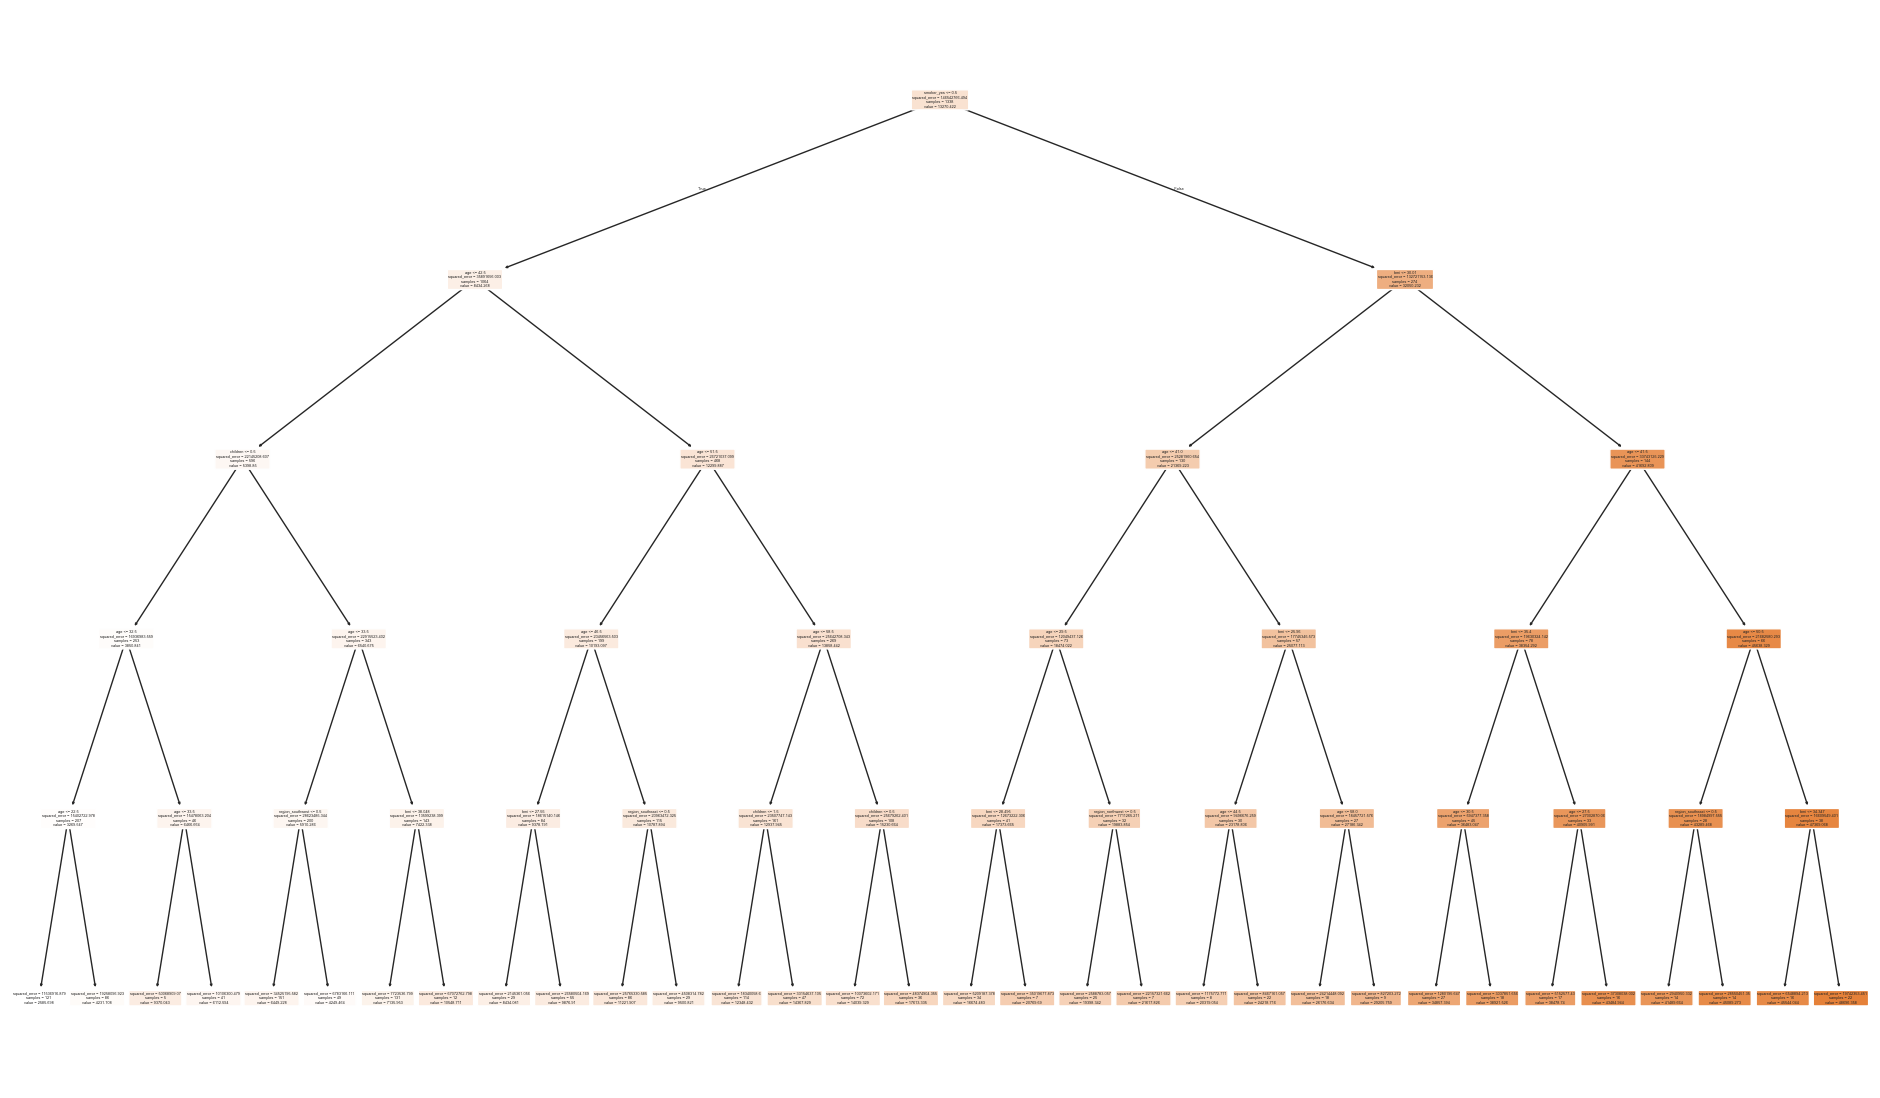

In [300]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Load your dataset prepare
df = pd.read_csv("insurance.csv").dropna()

# Use your selected model variables
best_terms = ['age', 'bmi', 'children', 'smoker', 'region']

# Convert categorical variables
df_dum = pd.get_dummies(df[best_terms], drop_first=True)

X = df_dum.values
y = df['charges'].values

# Fit the tree you identified as best
best_tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
).fit(X, y)

# Plot
plt.figure(figsize=(24, 14))
plot_tree(
    best_tree,
    feature_names=df_dum.columns,
    filled=True,
    rounded=True
)
plt.show()

Based on cross-validation, the regression tree outperformed the linear regression model by a large margin. The best tree (max_depth = 5, min_samples_leaf = 5) achieved an MSE of approximately 18.0 million, compared to 36.5 million for the linear model. Because medical charges exhibit strong nonlinearities and interactions (especially involving smoking status and BMI), the tree is better suited for capturing complex structure in the data. Therefore, the regression tree is preferred in this analysis due to its significantly superior predictive accuracy and ability to model nonlinear effects without imposing strict parametric assumptions.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [301]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

The file does not include headers, so we must assign column names manually.


In [302]:
url = location + dataframe

# Column names (from the UCI documentation)
columns = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

# Load dataset
df = pd.read_csv(url, header=None, names=columns)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


**Target Variable (Diagnosis)**

* 2 = Benign

* 4 = Malignant

This will be converted later to a binary variable (e.g., 0/1) for classification.

**Missing Data**

The bare_nuclei column includes missing values encoded as "?".

These must be handled by:

* Converting to numeric

* Dropping or imputing missing rows


In [303]:
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors='coerce')
df = df.dropna()

**Summary**

The Wisconsin Breast Cancer dataset contains 699 observations and 11 variables describing cell characteristics measured from fine-needle aspirates of breast tumors. Each tumor is labeled as either benign (class = 2) or malignant (class = 4). The dataset includes nine ordinal predictive features with values from 1 to 10 that quantify cell uniformity, clump thickness, adhesion, mitoses, and other morphological properties. One variable (bare_nuclei) contains missing values encoded as “?”. The data is intended for supervised binary classification and provides a classic benchmark for evaluating medical diagnostic models.


(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [304]:
import pandas as pd

# Load data
url = location + dataframe
columns = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

df = pd.read_csv(url, header=None, names=columns)

# Basic structure
print(df.info())
print(df.head())

# Convert bare_nuclei to numeric and check missing
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'], errors='coerce')
missing_counts = df.isna().sum()

print("\nMissing values:\n", missing_counts)
print("\nData types after conversion:\n", df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
None
        id  clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
0  1000025           

**Summary**

All variables are properly named and most are correctly typed as numeric. The only exception is the bare_nuclei variable, which originally contained missing values represented as "?". After converting this column to numeric, 16 observations become NaN. These missing values must be handled (typically by removing those rows) before fitting any predictive models. The target variable (class = 2 or 4) is correctly typed as integer and will later be recoded for classification. The id field is numeric but should not be used as a predictor, as it simply identifies each tumor sample.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [305]:
from sklearn.model_selection import train_test_split

# Load and clean data
url = location + dataframe

df = pd.read_csv(url, header=None, names=columns)

# Convert bare_nuclei to numeric and drop missing rows
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors="coerce")
df_clean = df.dropna()

# Drop the ID column
df_clean = df_clean.drop(columns=["id"])

# Split into training (70%) and test (30%) 
train_df, test_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

print("Training set size:", train_df.shape[0])
print("Test set size:", test_df.shape[0])


Training set size: 478
Test set size: 205


The dataset originally has 699 rows, and dropping the 16 missing bare_nuclei rows leaves 683 usable rows:

* 70% of 683 = 478
* 30% of 683 = 205

**Summary**

The dataset was randomly partitioned into a training and test set using a 70/30 split. After removing the 16 observations with missing values in the bare_nuclei variable, 683 complete cases remained. Using scikit-learn’s train_test_split function with a fixed random seed ensured reproducibility. The final training set contained approximately 70% of the data (478 cases), and the test set contained approximately 205 cases, which will be used later for evaluating model performance.


(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [306]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

url = location + dataframe

df = pd.read_csv(url, header=None, names=columns)
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors="coerce")
df_clean = df.dropna().drop(columns=["id"])

# Recode target variable: 2 = benign (0), 4 = malignant (1)
df_clean["class"] = df_clean["class"].map({2: 0, 4: 1})

# Split into train/test (70%/30%)
train_df, test_df = train_test_split(
    df_clean, test_size=0.30, random_state=42, shuffle=True
)

# Features and target
X_train = train_df.drop(columns=["class"])
y_train = train_df["class"]

X_test = test_df.drop(columns=["class"])
y_test = test_df["class"]

# Fit logistic regression
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

# Predict on test set
y_pred = logmodel.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report for more detail
print(classification_report(y_test, y_pred))


Confusion Matrix:
 [[125   2]
 [  7  71]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       127
           1       0.97      0.91      0.94        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

**Interpretation**

* True Negatives (TN): 125

Benign correctly classified as benign.

* True Positives (TP): 71

Malignant correctly classified as malignant.

* False Positives (FP): 2

Benign -> incorrectly classified as malignant.

* False Negatives (FN): 7

Malignant -> incorrectly classified as benign.

* Accuracy: 0.96 (96%)


**False Negatives (7 cases)**

These are malignant tumors incorrectly labeled benign.

**Medical consequences:**

* Missed or delayed cancer diagnosis

* Patient might not receive urgent treatment

* Cancer could progress or metastasize

* Potentially life-threatening

These errors are still far worse than false positives.

**False Positives (2 cases)**

Benign tumors wrongly predicted as malignant.

**Consequences:**

* Stress and anxiety

* Additional imaging or biopsy

* Extra cost

But no threat to life, diagnosis will eventually correct the mistake through follow-up tests.

Still much less harmful than false negatives.

**Summary**

The logistic regression model achieved 96% accuracy with a confusion matrix of [[125, 2], [7, 71]]. The model performs well overall, correctly identifying 71 malignant tumors and 125 benign ones. However, the model produced 7 false negatives (malignant tumors predicted as benign), which is the most concerning type of error in this medical context because it may delay essential treatment and allow the cancer to progress. Although false positives (2 cases) can cause stress and unnecessary follow-up procedures, they are far less dangerous than false negatives. Therefore, the most problematic errors in this setting are the false negatives, even though they are relatively few compared to the total number of malignant cases.


### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

1. Medical Diagnosis (e.g., identifying cancer from imaging or biomarkers)

* Response (class):

    * Benign vs. malignant tumor

* Predictors:

    * Imaging features (textures, shapes, masses)

    * Lab values (biomarkers, blood tests)

    * Patient characteristics (age, genetic markers)

* Goal: Both, but mostly prediction

    * Clinicians need a model that can accurately predict cancer to support diagnosis.

    * Some inference is also important (e.g., understanding which biomarkers are associated with malignancy), but the primary goal is accurate classification to support medical decisions.

2. Credit Scoring (deciding whether a customer is a good or bad credit risk)

* Response:

    * Approve loan (good credit) vs. deny loan (bad credit)

* Predictors:

    * Income, credit history, debt-to-income ratio

    * Employment status, payment history

    * Number of credit inquiries

* Goal: Prediction

    * Banks focus on minimizing risk and maximizing profit through accurate risk prediction, not necessarily inference about why each factor matters.

    * The emphasis is on classifying borrowers correctly.

3. Email Spam Detection

* Response:

    * Spam vs. not spam

* Predictors:

    * Word frequencies, sender reputation

    * Message length, presence of links or attachments

* Goal: Prediction

    * The primary objective is to automatically classify incoming emails accurately.


**Overall:** In classification applications, prediction accuracy is usually the top priority, though inference may sometimes play a secondary role when understanding variable importance matters.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

1. Predicting Housing Prices

* Response (continuous):

    * Sale price of a home (in dollars)

* Predictors:

    * Square footage, number of bedrooms/bathrooms

    * Location/neighborhood

    * Age of home, lot size, condition

* Goal: Prediction

    * Real estate companies, appraisers, and buyers focus on accurately forecasting sale prices.

    * Some inference may be useful (e.g., how much value an extra bedroom adds), but the main task is predicting the price.

2. Forecasting Medical Costs (Insurance Pricing)

* Response:

    * Annual healthcare cost for a patient

* Predictors:

    * Age, BMI, number of chronic conditions

    * Smoking status, region, prior year’s cost

* Goal: Both, but typically prediction

    * Insurers set premiums based on expected cost -> prediction.

    * However, policymakers or researchers might also want inference (e.g., understanding how smoking or chronic illness influences cost).

    * In industry, prediction is the primary goal.

3. Modeling Fuel Efficiency of Cars (MPG Prediction)

* Response:

    * Miles per gallon (mpg)

* Predictors:

    * Engine size, weight, horsepower

    * Fuel type, transmission type

    * Aerodynamic properties

* Goal: Inference or Prediction, depending on use-case

    * Automakers may want inference about which engineering factors have the largest impact on efficiency.

    * Consumers or regulators may want prediction to estimate mpg for new vehicle designs.

    * Either is possible, but inference is often more important for engineering decisions.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

**1. Advantages of a Very Flexible Model**

Flexible models include:

* Regression trees

* Random forests

* Neural networks

* High-degree polynomial regression

**Advantages**

* Can capture complex nonlinear relationships. Useful when the true relationship is highly irregular or involves interactions.

* Can achieve higher predictive accuracy. Flexible models adapt to patterns that rigid models (like linear regression) cannot capture.

* Better performance when the signal in the data is strong but complex. Examples: image classification, text sentiment analysis, medical imaging.


**2. Disadvantages of a Very Flexible Model**

* Higher risk of overfitting. They may fit noise instead of the underlying pattern, especially with small sample sizes.

* Lower interpretability. Harder (sometimes impossible) to explain coefficients or decision rules.

* Require more data and computational power. Complex models need more training data to generalize well.

* Harder to diagnose or troubleshoot. They often behave as “black boxes.”



**3. Advantages of a Less Flexible Model**

These are examples:

* Linear regression

* Logistic regression

* Simple classification trees

* Low-degree polynomials

**Advantages**

* Easier to interpret. Coefficients have clear meaning (e.g., effect of BMI on charges).

* Lower risk of overfitting. Simpler structure makes them more stable and reliable with limited data.

* Require fewer observations. Less flexible models perform well even with small datasets.

* Faster and easier to compute. Good for quick analysis or when computational resources are limited.

**4. Disadvantages of a Less Flexible Model**

* May underfit. Unable to capture important nonlinear relationships.

* Lower predictive accuracy when patterns are complex. Poor performance on tasks like image recognition or speech classification.

* Makes unrealistic assumptions. Example: linear regression assumes linearity, homoscedasticity, and additive effects.


**5. When Is a More Flexible Approach Preferred?**

A flexible model is preferred when:

* The underlying relationship between predictors and response appears highly nonlinear or complex

* There is a large amount of training data

* Prediction accuracy is more important than model interpretability

* Overfitting can be mitigated using cross-validation or regularization

* The problem is inherently complex (e.g., medical imaging, natural language processing)


**6. When Is a Less Flexible Approach Preferred?**

A simpler, less flexible model is preferred when:

* Interpretability is important (e.g., medical or legal decisions)

* The dataset is small or noisy

* There is a need for stable, generalizable performance

* The goal is inference, not prediction. Example: understanding how smoking influences cancer risk


**Summary**

* Flexible models = higher predictive power, lower interpretability, higher risk of overfitting

* Less flexible models = more interpretable, more stable, but may miss real nonlinear relationships

* The choice depends on: goal of analysis, data size, complexity of relationships, and need for interpretability


### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

**The correct Answer iii.**

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

The fitted least-squares regression function is

    Y^ = β0 + β1.X1 + β2.X2 + β3.X3 + β4.X4 + β5.X5

where

* X1=GPA

* X2=IQ

* X3=Gender (1 = female, 0 = male)

* X4=X1X2=GPA×IQ

* X5=X1X3=GPA×Gender

and the estimated coefficients are

    β=50, β1=20, β2=0.07, β3=35, β4=0.01, β5=−10.
    
So the least-squares prediction function is

    Y^=50+20⋅GPA+0.07⋅IQ+35⋅Gender+0.01(GPA⋅IQ)−10(GPA⋅Gender)

(with Y^ in thousands of dollars).


**Prediction for a female with IQ = 110 and GPA = 4.0**

Here GPA = 4, IQ = 110, Gender = 1.

Y^	=50+20(4)+0.07(110)+35(1)+0.01(4⋅110)−10(4⋅1)
	=50+80+7.7+35+4.4−40
	=137.1

**So the predicted starting salary is 137.1 thousand dollars.**


(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

**This statement is __false__.**

Why false?

1. Coefficient size must be interpreted relative to the scale of the variables.
The interaction term is

0.01×(GPA×IQ).

GPA is roughly between 0 and 4, IQ around 80 and 140, so the product GPA·IQ can easily be around 400 and 500.
Then the interaction contribution is between

0.01x400=4.0 and 0.01x500=5.0

Four or five thousand dollars, which is not small in the context of salaries.

2. “Small” numerically doesn’t mean “statistically insignificant.”
To say there is “little evidence of an interaction,” we would need to look at:

    * the standard error of the interaction coefficient,

    * a t-statistic or p-value, not just the raw magnitude of the coefficient.

So, even though the coefficient 0.01 looks small as a number, given the scale of GPA × IQ and without seeing its standard error, we cannot conclude there is little evidence of an interaction effect.


### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.


The likelihood for the sample is

$$
L(\theta) = \prod_{i=1}^n \frac{e^{-\theta}\theta^{x_i}}{x_i!}
= e^{-n\theta}\theta^{\sum_{i=1}^n x_i} \Big/ \prod_{i=1}^n x_i!.
$$

Take logs:

$$
\ell(\theta) = \log L(\theta)
= -n\theta + \left(\sum_{i=1}^n x_i\right)\log\theta - \sum_{i=1}^n \log(x_i!).
$$

Differentiate and set equal to zero:

$$
\ell'(\theta)
= -n + \frac{\sum_{i=1}^n x_i}{\theta} = 0
\quad\Rightarrow\quad
\hat{\theta} = \frac{1}{n}\sum_{i=1}^n x_i = \bar{X}.
$$

Second derivative:

$$
\ell''(\theta) = -\frac{\sum_{i=1}^n x_i}{\theta^2}.
$$

If at least one observed value is nonzero, then $\sum x_i > 0$, and for any $\theta > 0$,

$$
\ell''(\hat{\theta}) = -\frac{\sum x_i}{\hat{\theta}^2} < 0,
$$

so $\ell(\theta)$ is concave at $\hat{\theta}$ and this critical point is a **global maximum**.

$$
\boxed{
\hat{\theta}_{\text{MLE}} = \bar{X}
= \frac{1}{n}\sum_{i=1}^n X_i
\quad\text{when at least one } X_i \neq 0.
}
$$




(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

Now suppose every observed value is zero: 
$$
x_1 = \cdots = x_n = 0.
$$

Then the likelihood reduces to

$$
L(\theta)
= \prod_{i=1}^n \frac{e^{-\theta}\theta^0}{0!}
= \prod_{i=1}^n e^{-\theta}
= e^{-n\theta}, \qquad \theta > 0.
$$

The log-likelihood is

$$
\ell(\theta) = -n\theta.
$$

This is a strictly decreasing function of $\theta$ on $(0, \infty)$, so:

* The larger $\theta$ is, the smaller the likelihood.  
* The likelihood is maximized by taking $\theta$ as small as possible.

The supremum of $L(\theta) = e^{-n\theta}$ occurs as $\theta \to 0^+$:

$$
\lim_{\theta \to 0^+} L(\theta) = e^0 = 1.
$$

But $\theta = 0$ is not in the parameter space (we assumed $\theta > 0$, not $\theta \ge 0$).

Therefore:

* There is **no value** $\theta > 0$ at which the likelihood attains its maximum.  
* The MLE **does not exist** under the constraint $\theta > 0$.

(If we had allowed $\theta \ge 0$, the MLE would be $\hat{\theta} = 0$.)



### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [307]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

NameError: name 'get_songs' is not defined

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  